# Section 1 - Perform Quantum Operations

## Certification weight: 16%

## Objectives 

- Define Pauli operators
- Apply quantum operations




# Pauli operators

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.Pauli

A Pauli operator O is a sum of Pauli strings: $ O = \displaystyle\sum_{i} C_{i}P_{i} $



## The building blocks
There are four Pauli operators, operating in a single qubit:

**I -> Identity:**
$$I = \begin{bmatrix}1 & 0 \\ 0 & 1\end{bmatrix}$$
It leaves the qubit as it, without modification

**X -> Pauli‑X** (bit flip):
$$X = \begin{bmatrix}0 & 1 \\ 1 & 0\end{bmatrix}$$
Flips |0⟩ ↔ |1⟩. Acts as the quantum NOT gate.

**Y -> Pauli‑Y** (bit flip and phase flip):
$$Y = \begin{bmatrix}0 & -i \\ i & 0\end{bmatrix}$$
Combines a bit flip and a 90° phase shift

**Z -> Pauli‑Z** (phase flip):
$$Z = \begin{bmatrix}1 & 0 \\ 0 & -1\end{bmatrix}$$
Leaves |0⟩ alone but flips the phase of |1⟩: |1⟩ → -|1⟩

Those operator are the building blocks of quantum computing: they describe, manipulate and measure quantum systems; and are heavily used in Qiskit!

In practice, Pauli operators are used:
- as quantum gates: each gate created from a Pauli will apply its associated matrix
- as observables: the Estimator primitive (section 6) uses express results as a sum of Pauli operators
- as Hamiltonians (the total energy of the system)

In qiskit, the Paulis explained above can be added directly in a circuit, using the `x`, `y` and `z`functions of a `QuantumCircuit`:

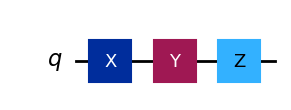

In [1]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)

qc.x(0)  # Pauli-X
qc.y(0)  # Pauli-Y
qc.z(0)  # Pauli-Z

qc.draw('mpl')

## Pauli creation

Pauli can be created and maniuplated with the Pauli objects

We can create a Pauli using a string, a matrix, or a list

### Creating a Pauli from a string

A Pauli string a a tensor product of the Paulis. For example:
- $ X \otimes I \otimes Z $ is equivalent to `XIZ`
- $ Z \otimes Z $ is equivalent to `ZZ`

A Pauli is created using the `Pauli(obj)` function, and a Pauli can be displayed as a matrix using `to_matrix()`

In [2]:
from qiskit.quantum_info import Pauli
pauliX = Pauli('X')
pauliX.to_matrix()

array([[0.+0.j, 1.+0.j],
       [1.+0.j, 0.+0.j]])

In [3]:
PauliXY = Pauli('XY') # X on qubit 1, Y on qubit 0
PauliXY.to_matrix()

array([[0.+0.j, 0.+0.j, 0.+0.j, 0.-1.j],
       [0.+0.j, 0.+0.j, 0.+1.j, 0.+0.j],
       [0.+0.j, 0.-1.j, 0.+0.j, 0.+0.j],
       [0.+1.j, 0.+0.j, 0.+0.j, 0.+0.j]])

We can verify that the Pauli `XY` is equivalent to the tensor product (or outer product) of the respective arrays of X and Y:

In [4]:
import numpy as np
matX = np.array([[0.+0.j, 1.+0.j],
       [1.+0.j, 0.+0.j]])
matY = np.array([[0.+0.j, 0.-1.j],
       [0.+1.j, 0.+0.j]])

np.kron(matX, matY) # outer product

array([[0.+0.j, 0.+0.j, 0.+0.j, 0.-1.j],
       [0.+0.j, 0.+0.j, 0.+1.j, 0.+0.j],
       [0.+0.j, 0.-1.j, 0.+0.j, 0.+0.j],
       [0.+1.j, 0.+0.j, 0.+0.j, 0.+0.j]])

When creating a Pauli with just one letter, it will create a 2-dimension matrix.
With 2 letters -> 4 dimensions
...

## Creating a Pauli from a list with PauliList

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.quantum_info.PauliList

A PauliList is  container for multiple Pauli Operators. It's sometimes easier to declare, store and iterate using this object

In [10]:
from qiskit.quantum_info import PauliList, Pauli

pl = PauliList(['XIZ', 'YYI', 'ZZZ'])

# We can iterate it like a table
for i in pl:
    print(Pauli(i))

print("---\nOr accessing it using the index :", Pauli(pl[2]))

XIZ
YYI
ZZZ
---
Or accessing it using the index : ZZZ


## Sparse Paulis

A `SparsePauliOp` is a linear combination of Pauli strings. Internally, it's composed of a PauliList and and a NumPy array for storing the coefficients.

$\displaystyle\sum_{k} c_kP_k$

with: 
- $c_k$ is a coefficient, $ c_k \in \mathbb{C} $
- $P_k$ is a Pauli string, $ P_k \in \{I,X,Y,Z\}^{\otimes n} $



A simple hamiltionian can be created using strings.

Let's create the following one: $ H = 0.5ZI + 0.5 IZ - 0.5ZZ $

In [12]:
from qiskit.quantum_info import SparsePauliOp

SparsePauliOp(
    ["ZI", "IZ", "ZZ"],
    coeffs=[0.5, 0.5, -0.5]
)

SparsePauliOp(['ZI', 'IZ', 'ZZ'],
              coeffs=[ 0.5+0.j,  0.5+0.j, -0.5+0.j])

A more complex one can be created using a `sparse_list`

In [15]:
from qiskit.quantum_info import SparsePauliOp

# Define three terms
sparse_list = [
    ('X', [0], 1.0),   # X on qubit 0, coefficient 1.0
    ('Z', [1], -0.5),  # Z on qubit 1, coefficient -0.5
    ('YZ', [1,3], 1.2j) # Y on qubits 1 and Z on qubit 3, coefficient 1.2j
]

sparse = SparsePauliOp.from_sparse_list(sparse_list, num_qubits=4)
sparse

SparsePauliOp(['IIIX', 'IIZI', 'ZIYI'],
              coeffs=[ 1. +0.j , -0.5+0.j ,  0. +1.2j])

From the documentation example:

```
op1 = SparsePauliOp.from_sparse_list(
    [("ZX", [1, 4], 1.0), ("YY", [0, 3], -1 + 1j)], num_qubits=5)
op1
```

- The first term: `("ZX", [1, 4], 1.0)`
"ZX" → the Pauli types in this string:
- Z acts on qubit 1
- X acts on qubit 4
- [1, 4] → the indices of the qubits the Pauli operators act on
- 1.0 → coefficient (just a scalar multiplier for this Pauli string)

So mathematically, this term is:
$ 1 * I_0 \otimes Z_1 \otimes I_2 \otimes I_3 \otimes X_4$

- The second term: `("YY", [0, 3], -1 + 1j)`
- "YY" → two Y operators
- [0, 3] → first Y acts on qubit 0, second Y acts on qubit 3
- -1 + 1j → complex coefficient
equivalent to :
$(-1 + j) Y_0 \otimes I_1 \otimes I_2 \otimes Y_3 \otimes I_4$

Get the number of qubit of a Pauli using .numqubits attribute:

## Operations on Paulis

We can perform some operations on paulis, and get some informations

### Core algebra of Paulis
We can multiply Paulis, and we get another Pauli, plus a phase:

- XY = iZ
- YZ = iX
- ZX = iY

In [17]:
from qiskit.quantum_info import Pauli

p1 = Pauli("X")
p2 = Pauli("Y")

result = p1 @ p2
print("result:" ,result)

result: iZ


We can do the same with `compose`

A.compose(B) is the equivalent to B.dot(A)

In [20]:
p1.compose(p2) 

Pauli('-iZ')

In [36]:
PauliToDetermine = Pauli('IXZYZI')
PauliToDetermine.num_qubits

6

In [ ]:
PauliToDetermine.phase

# The Pauli operator

The operator class stores the operations as a matrix, so, it's memory-consuming -> use it for small circuits



In [71]:
# Create an Operator from a Pauli object
from qiskit.quantum_info import Operator, Pauli

pauliXX = Pauli("XX")
Operator(pauliXX)

Operator([[0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
          [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
          [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [32]:
Operator(pauliXX) == Operator(np.kron(matX,matX))

True

In [35]:
pauliX = Pauli('Z')
pauliX.to_matrix()

array([[ 1.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j]])

# Convert a Pauli into instructions usable in a circuit
It's possible to convert a Pauli object into an object that can be added in a circuit, using `to_instruction()`. This object is not a gate, thus, it has to be added using `append` to a circuit

For information, when transpiled, 
- X = $R_x(\pi)$
- Y = $R_y(\pi)$
- Z = $R_z(\pi)$

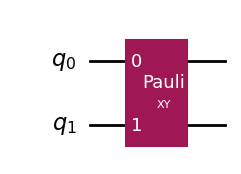

In [5]:
from qiskit.circuit import QuantumCircuit

myPauli = Pauli("XY")       # X on q1 and Y on q0
instruction = myPauli.to_instruction()

# Add it in a circuit
qc = QuantumCircuit(2)
qc.append(instruction, [0, 1])
qc.draw("mpl")

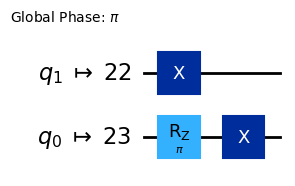

In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime.fake_provider import FakeFez
backend = FakeFez()
transpiled = transpile(qc, backend)
transpiled.draw("mpl")

We can see that X is applied on Q1, and Y on Q0 (in fact, Y == -ZX)

# Pauli Compostion
Add a transformation to a Pauli with .compose, like a matrix multiplication
Works only with Paulis objects
The operation is done on the same qubit!

In [59]:
myPauliX = Pauli('X')
myPauliComposed = myPauliX.compose('Y')
myPauliComposed.to_matrix()

array([[0.-1.j, 0.+0.j],
       [0.+0.j, 0.+1.j]])

In [62]:
matY @ matX

array([[0.-1.j, 0.+0.j],
       [0.+0.j, 0.+1.j]])

In [63]:
myPauliComposed

Pauli('-iZ')

# Pauli and tensor products

It's possible to create a pauli sequentially

In [70]:
myPauliX = Pauli('X')
myPauliZ = Pauli('Z')

myPauliTensor = myPauliX.tensor(myPauliZ)   # X ⊗ Z
print("Pauli Created:", myPauliTensor.to_label())
print(myPauliTensor.to_matrix())

Pauli Created: XZ
[[ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j]]


In [66]:
Pauli('XZ').to_matrix()

array([[ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j],
       [ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j]])

In [ ]:
https://quantum.cloud.ibm.com/docs/en/guides/operators-overview 